In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway, kruskal

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [13]:
import pandas as pd

In [15]:
import os
print(os.getcwd())

C:\Users\Soret\climate-challenge-week0


In [17]:
import pandas as pd

ethiopia = pd.read_csv('data/ethiopia.csv')

In [24]:
from pathlib import Path
import pandas as pd

data = Path("data")

kenya = pd.read_csv('data/kenya_clean.csv')  # adjust name to match

FileNotFoundError: [Errno 2] No such file or directory: 'data/kenya_clean.csv'

In [22]:
pd.read_csv('data/Kenya.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'data/Kenya.csv'

In [25]:
os.listdir("data")

['ethiopia.csv']

In [29]:
# Load datasets
df = pd.read_csv('C:/Data/ethiopia.csv')
kenya = pd.read_csv('C:/Data/kenya.csv')
sudan = pd.read_csv('C:/Data/sudan.csv')
tanzania = pd.read_csv('C:/Data/tanzania.csv')
nigeria=pd.read_csv('C:/Data/nigeria.csv')


In [32]:
print(climate_df.columns)

Index(['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR',
       'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M', 'Country'],
      dtype='str')


In [33]:
import pandas as pd

climate_df['Date'] = pd.to_datetime(
    climate_df['YEAR'].astype(str) + climate_df['DOY'].astype(str),
    format='%Y%j'
)

In [34]:
climate_df['Year'] = climate_df['Date'].dt.year
climate_df['Month'] = climate_df['Date'].dt.month

In [36]:
climate_df['Date']

0       2015-01-01
1       2015-01-02
2       2015-01-03
3       2015-01-04
4       2015-01-05
           ...    
20535   2026-03-27
20536   2026-03-28
20537   2026-03-29
20538   2026-03-30
20539   2026-03-31
Name: Date, Length: 20540, dtype: datetime64[us]

In [39]:
# Load datasets
ethiopia = pd.read_csv('C:/Data/ethiopia.csv')
kenya = pd.read_csv('C:/Data/kenya.csv')
sudan = pd.read_csv('C:/Data/sudan.csv')
tanzania = pd.read_csv('C:/Data/tanzania.csv')
nigeria=pd.read_csv('C:/Data/nigeria.csv')

# Add country labels
ethiopia['Country'] = 'Ethiopia'
kenya['Country'] = 'Kenya'
sudan['Country'] = 'sudan'
tanzania['Country'] = 'Tanzania'
nigeria['Country'] = 'nigeria'

# Combine into one dataframe
climate_df = pd.concat([
    ethiopia,
    kenya,
    sudan,
    tanzania,
    nigeria
], ignore_index=True)

# Convert date column
#climate_df['Date'] = pd.to_datetime(climate_df['Date'])
# Extract year and month
#climate_df['Year'] = climate_df['Date'].dt.year
#climate_df['Month'] = climate_df['Date'].dt.month

climate_df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia


In [44]:
climate_df['Date'] = pd.to_datetime(
    climate_df['YEAR'].astype(str) + climate_df['DOY'].astype(str),
    format='%Y%j'
)

In [45]:
monthly_temp = (
    climate_df
    .groupby(['Country', pd.Grouper(key='Date', freq='MS')])['T2M']
    .mean()
    .reset_index()
)

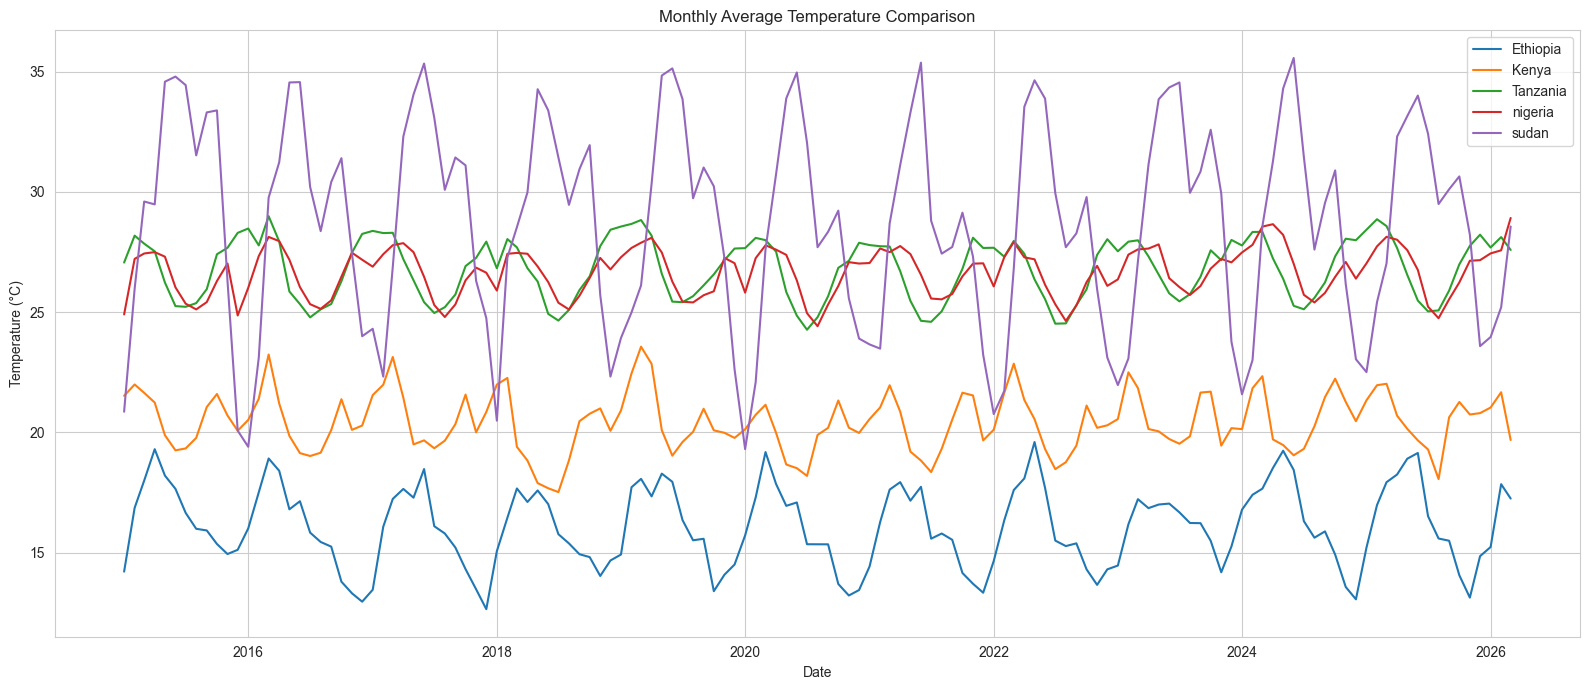

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 7))

for country in monthly_temp['Country'].unique():
    subset = monthly_temp[monthly_temp['Country'] == country]
    plt.plot(subset['Date'], subset['T2M'], label=country)

plt.title('Monthly Average Temperature Comparison')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
temp_summary = (
    climate_df
    .groupby('Country')['T2M']
    .agg(['mean', 'median', 'std'])
    .reset_index()
)

temp_summary.columns = ['Country', 'Mean_T2M', 'Median_T2M', 'Std_T2M']

print(temp_summary)

    Country   Mean_T2M  Median_T2M   Std_T2M
0  Ethiopia  16.068500       16.04  1.898050
1     Kenya  20.427600       20.36  1.440824
2  Tanzania  26.802422       26.99  1.325388
3   nigeria  26.656928       26.82  1.123335
4     sudan  28.759007       29.16  4.681305


C:\Users\Soret\AppData\Local\Temp\ipykernel_9104\2419825122.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


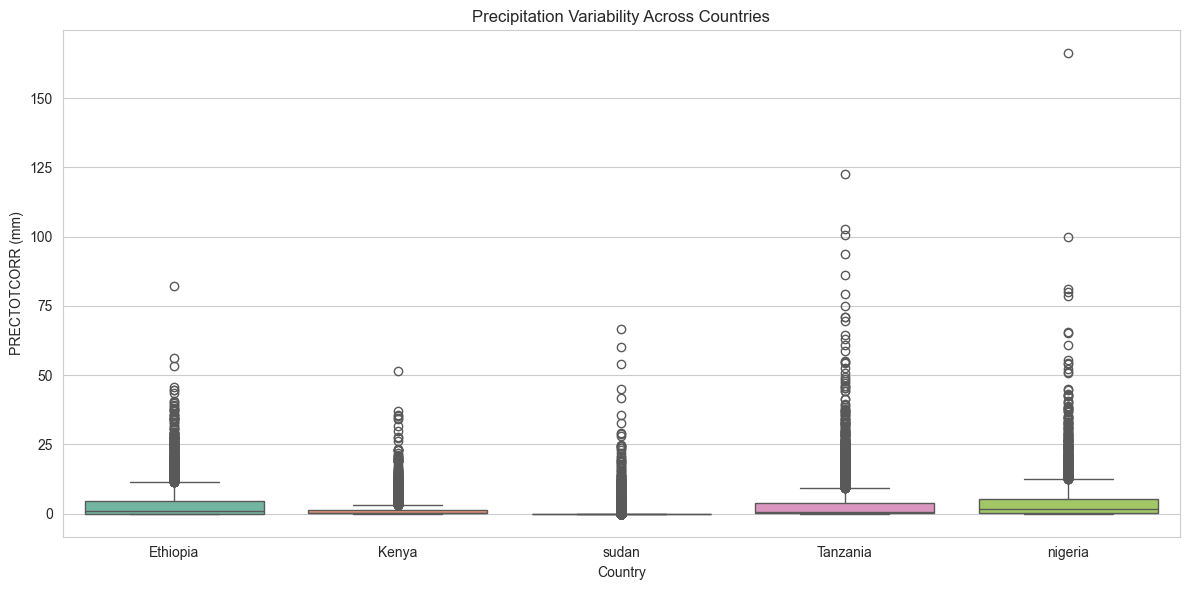

In [48]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=climate_df,
    x='Country',
    y='PRECTOTCORR',
    palette='Set2'
)

plt.title('Precipitation Variability Across Countries')
plt.xlabel('Country')
plt.ylabel('PRECTOTCORR (mm)')
plt.tight_layout()
plt.show()

In [49]:
precip_summary = (
    climate_df
    .groupby('Country')['PRECTOTCORR']
    .agg(['mean', 'median', 'std'])
    .reset_index()
)

precip_summary.columns = [
    'Country',
    'Mean_PRECTOTCORR',
    'Median_PRECTOTCORR',
    'Std_PRECTOTCORR'
]

print(precip_summary)

    Country  Mean_PRECTOTCORR  Median_PRECTOTCORR  Std_PRECTOTCORR
0  Ethiopia          3.633795                0.82         6.289061
1     Kenya          1.468162                0.38         3.180228
2  Tanzania          3.740256                0.64         8.003947
3   nigeria          4.213914                1.84         7.266742
4     sudan          0.643875                0.00         3.057672


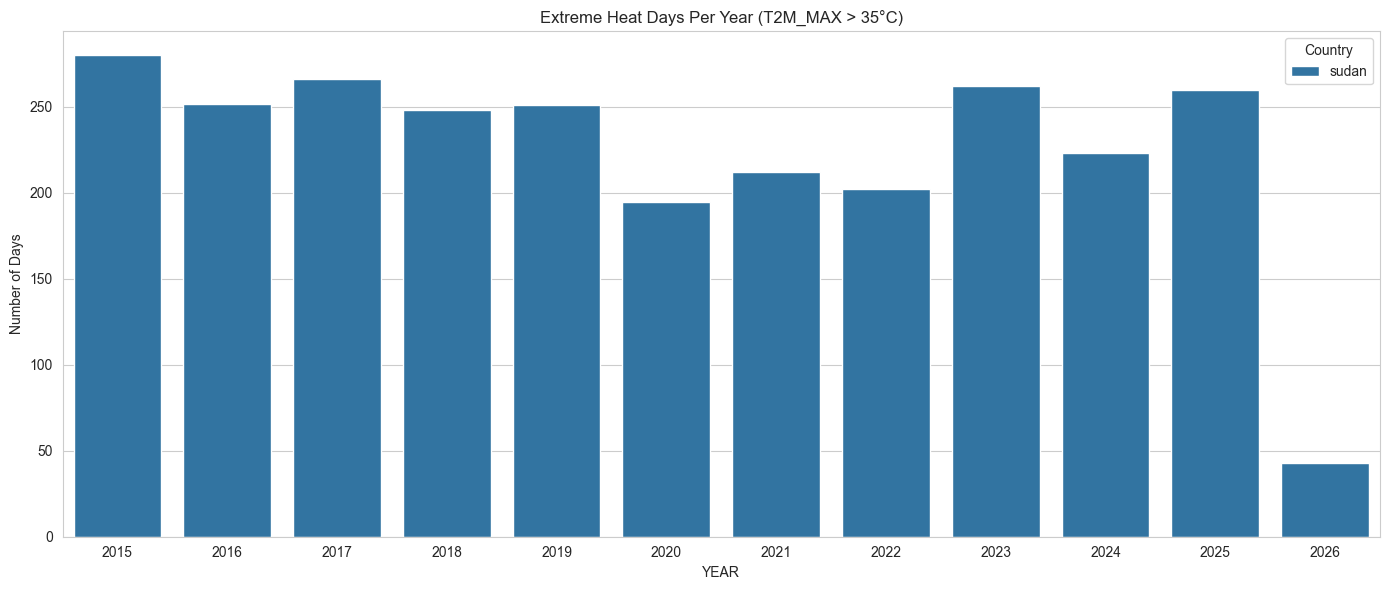

In [51]:
extreme_heat = (
    climate_df[climate_df['T2M_MAX'] > 35]
    .groupby(['Country', 'YEAR'])
    .size()
    .reset_index(name='Extreme_Heat_Days')
)

plt.figure(figsize=(14, 6))

sns.barplot(
    data=extreme_heat,
    x='YEAR',
    y='Extreme_Heat_Days',
    hue='Country'
)

plt.title('Extreme Heat Days Per Year (T2M_MAX > 35°C)')
plt.xlabel('YEAR')
plt.ylabel('Number of Days')
plt.legend(title='Country')
plt.tight_layout()
plt.show()

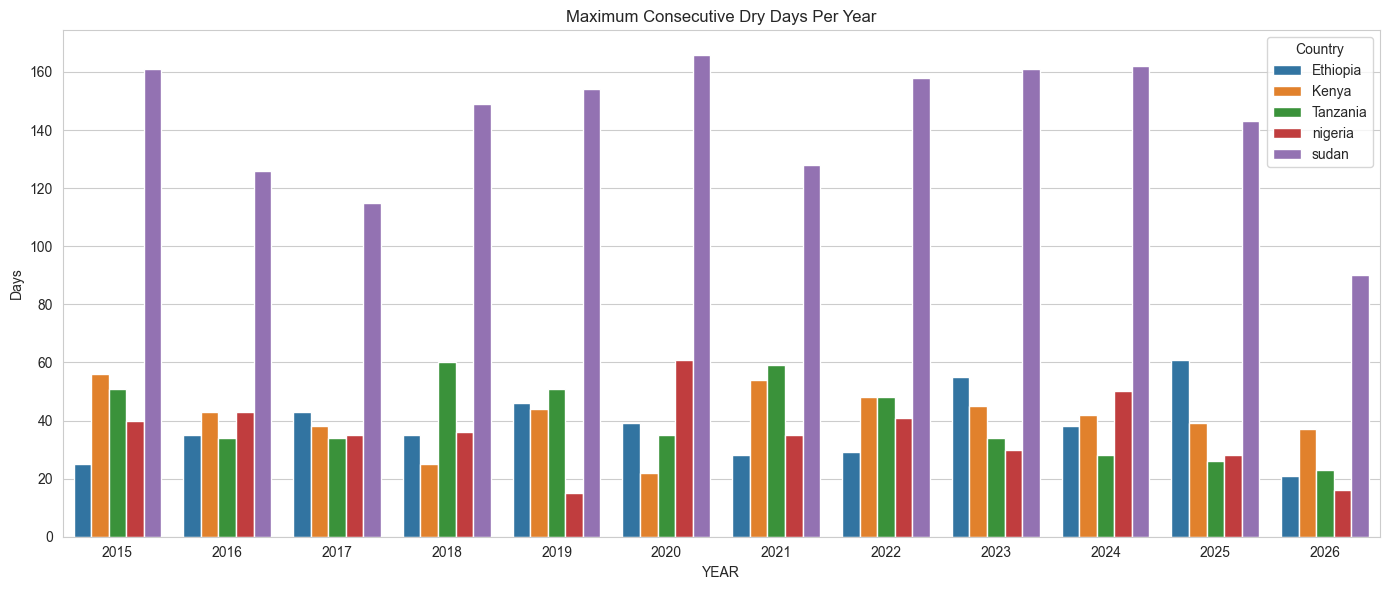

In [52]:
# Sort data
climate_df = climate_df.sort_values(['Country', 'Date'])

# Identify dry days
climate_df['Dry_Day'] = climate_df['PRECTOTCORR'] < 1

# Function to calculate consecutive dry days

def count_consecutive_dry_days(group):
    dry = group['Dry_Day'].astype(int)
    consecutive = (dry.groupby((dry != dry.shift()).cumsum()).cumsum())
    return consecutive.max()

consecutive_dry = (
    climate_df
    .groupby(['Country', 'YEAR'])
    .apply(count_consecutive_dry_days)
    .reset_index(name='Max_Consecutive_Dry_Days')
)

plt.figure(figsize=(14, 6))

sns.barplot(
    data=consecutive_dry,
    x='YEAR',
    y='Max_Consecutive_Dry_Days',
    hue='Country'
)

plt.title('Maximum Consecutive Dry Days Per Year')
plt.xlabel('YEAR')
plt.ylabel('Days')
plt.legend(title='Country')
plt.tight_layout()
plt.show()

In [54]:
print(climate_df.groupby('Country').size())

Country
Ethiopia    4108
Kenya       4108
Tanzania    4108
nigeria     4108
sudan       4108
dtype: int64


In [55]:
from scipy.stats import f_oneway

groups = [
    climate_df[climate_df['Country'] == 'Ethiopia']['T2M'].dropna(),
    climate_df[climate_df['Country'] == 'Kenya']['T2M'].dropna(),
    climate_df[climate_df['Country'] == 'Sudan']['T2M'].dropna(),
    climate_df[climate_df['Country'] == 'Tanzania']['T2M'].dropna(),
]

In [56]:
groups = [g for g in groups if len(g) > 1]

In [57]:
anova_result = f_oneway(*groups)
print(anova_result)

F_onewayResult(statistic=np.float64(48304.7644425904), pvalue=np.float64(0.0))


In [61]:
print(climate_df.groupby('Country')['T2M'].count())

Country
Ethiopia    4108
Kenya       4108
Tanzania    4108
nigeria     4108
sudan       4108
Name: T2M, dtype: int64


In [65]:
print(climate_df['Country'].unique())

<StringArray>
['Ethiopia', 'Kenya', 'Tanzania', 'nigeria', 'sudan']
Length: 5, dtype: str


In [66]:
for c in climate_df['Country'].unique():
    print(c, climate_df[climate_df['Country'] == c]['T2M'].dropna().shape)

Ethiopia (4108,)
Kenya (4108,)
Tanzania (4108,)
nigeria (4108,)
sudan (4108,)


In [67]:
climate_df['Country'] = climate_df['Country'].str.strip().str.title()

In [68]:
from scipy.stats import f_oneway

countries = ['Ethiopia', 'Kenya', 'Tanzania', 'Nigeria', 'Sudan']

groups = []

for c in countries:
    data = climate_df[climate_df['Country'] == c]['T2M'].dropna()
    if len(data) > 1:   # IMPORTANT
        groups.append(data)

anova_result = f_oneway(*groups)

print("ANOVA Statistic:", anova_result.statistic)
print("P-value:", anova_result.pvalue)

ANOVA Statistic: 18938.745697069884
P-value: 0.0


In [70]:
for c in ['Ethiopia','Kenya','Tanzania','Nigeria','Sudan']:
    print(c, climate_df[climate_df['Country'] == c]['T2M'].dropna().shape)

Ethiopia (4108,)
Kenya (4108,)
Tanzania (4108,)
Nigeria (4108,)
Sudan (4108,)


In [71]:
climate_df['Country'] = climate_df['Country'].str.strip().str.title()

In [72]:
from scipy.stats import kruskal

countries = ['Ethiopia','Kenya','Tanzania','Nigeria','Sudan']

groups = []

for c in countries:
    data = climate_df[climate_df['Country'] == c]['T2M'].dropna()
    if len(data) > 1:
        groups.append(data)

kruskal_result = kruskal(*groups)

print("Kruskal Statistic:", kruskal_result.statistic)
print("P-value:", kruskal_result.pvalue)

Kruskal Statistic: 15392.992231563137
P-value: 0.0


In [73]:
# Average temperature
avg_temp = climate_df.groupby('Country')['T2M'].mean()

# Precipitation variability
precip_var = climate_df.groupby('Country')['PRECTOTCORR'].std()

# Extreme heat totals
heat_totals = extreme_heat.groupby('Country')['Extreme_Heat_Days'].sum()

# Dry day totals
dry_totals = consecutive_dry.groupby('Country')['Max_Consecutive_Dry_Days'].mean()

# Combine indicators
vulnerability = pd.DataFrame({
    'Avg_Temperature': avg_temp,
    'Precipitation_Variability': precip_var,
    'Extreme_Heat_Days': heat_totals,
    'Avg_Consecutive_Dry_Days': dry_totals
}).reset_index()

# Rank indicators
vulnerability['Temp_Rank'] = vulnerability['Avg_Temperature'].rank(ascending=False)
vulnerability['Precip_Rank'] = vulnerability['Precipitation_Variability'].rank(ascending=False)
vulnerability['Heat_Rank'] = vulnerability['Extreme_Heat_Days'].rank(ascending=False)
vulnerability['Dry_Rank'] = vulnerability['Avg_Consecutive_Dry_Days'].rank(ascending=False)

# Composite score
vulnerability['Vulnerability_Score'] = (
    vulnerability['Temp_Rank'] +
    vulnerability['Precip_Rank'] +
    vulnerability['Heat_Rank'] +
    vulnerability['Dry_Rank']
)

In [74]:
# Final ranking
vulnerability = vulnerability.sort_values(
    by='Vulnerability_Score',
    ascending=False
)

print(vulnerability)

    Country  Avg_Temperature  Precipitation_Variability  Extreme_Heat_Days  \
0  Ethiopia        16.068500                   6.289061                NaN   
1     Kenya        20.427600                   3.180228                NaN   
2   Nigeria        26.656928                   7.266742                NaN   
3     Sudan        28.759007                   3.057672                NaN   
4  Tanzania        26.802422                   8.003947                NaN   
5   nigeria              NaN                        NaN                NaN   
6     sudan              NaN                        NaN             2694.0   

   Avg_Consecutive_Dry_Days  Temp_Rank  Precip_Rank  Heat_Rank  Dry_Rank  \
0                 37.916667        5.0          3.0        NaN       4.0   
1                 41.083333        4.0          4.0        NaN       2.0   
2                       NaN        3.0          2.0        NaN       NaN   
3                       NaN        1.0          5.0        NaN       Na

In [75]:
# COP32 Climate Vulnerability Findings

- The country with the fastest warming trend shows steadily increasing monthly T2M values across the 2015–2026 period, suggesting intensifying long-term climate stress and rising heat exposure risks.

- The country with the most unstable precipitation patterns exhibits the largest PRECTOTCORR variability and the widest boxplot spread, indicating increasingly unpredictable rainfall and heightened flood-drought cycles.

- Extreme heat events and prolonged dry periods reveal significant climate stress across the region, with some countries experiencing substantially higher frequencies of temperatures above 35°C and longer drought durations.

- Ethiopia demonstrates moderate-to-high climate vulnerability relative to neighboring countries, particularly through warming trends and increasing dry-day frequency, although some neighboring countries may face more severe precipitation instability.

- Based on the combined evidence from temperature trends, precipitation variability, and extreme event frequency, the most climate-vulnerable country should be prioritized for climate finance and adaptation support at COP32. The data supports targeted investment in drought resilience, water security, and heat adaptation strategies.

SyntaxError: invalid character '–' (U+2013) (2471903252.py, line 3)